<a href="https://colab.research.google.com/github/DylanSanchz/Quantum-Circuits/blob/main/CircuitodeBell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Instalamos la libreria

In [ ]:
pip install 'qiskit [visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 46.1 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2c867ee85338b16cadd442e7db5bbd9c7fa55e08db9eade3528b2c0d4350d918
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
!pip install pennylane jax jaxlib jaxopt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 986.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.5 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
from jax import numpy as np
import jax

## Creamos el simulador "Device"

In [ ]:
# Creamos un dispositivo cuántico simulado
# "lightning.qubit" → simulador rápido de qubits
# wires=1 → solo usamos 1 qubit

dev = qml.device("lightning.qubit", wires=1)

## Definimos el Circuito Cuantico

In [ ]:
# Definimos un QNode: una función cuántica ejecutable
@qml.qnode(dev)
def circuit(params):
    """
    params: array con dos parámetros [phi, theta]

    Este circuito:
    1. Aplica una rotación RX
    2. Luego una rotación RY
    3. Mide el valor esperado de Pauli-Z
    """

    # Rotación alrededor del eje X
    qml.RX(params[0], wires=0)

    # Rotación alrededor del eje Y
    qml.RY(params[1], wires=0)

    # Medición del observable Z
    # Resultado entre -1 y 1
    return qml.expval(qml.PauliZ(0))

Estamos moviendo el Qbit

## Ejecutamos el Circuito

In [ ]:
# Definimos parámetros iniciales
params = np.array([0.54, 0.12])

# Ejecutamos el circuito
resultado = circuit(params)

print("Resultado del circuito:", resultado)

Resultado del circuito: 0.85154057


Cercano a +1, estado |0>
Cercano a -1, estado |1>

## Calculamos el gradiente

In [ ]:
# Calculamos el gradiente del circuito respecto a los parámetros
dcircuit = jax.grad(circuit)

gradiente = dcircuit(params)

print("Gradiente:", gradiente)

Gradiente: [-0.5104387  -0.10267819]


Entrena el circuito como una red neuronal

## Funcion costo

In [ ]:
# La función de costo es simplemente el output del circuito
# Queremos minimizarla → llegar a -1

def cost(x):
    return circuit(x)

## Parametros

In [ ]:
# Valores iniciales pequeños
params = np.array([0.011, 0.012])

print("Costo inicial:", cost(params))

Costo inicial: 0.9998675


## Optimizacion

In [ ]:
import jaxopt

In [ ]:
# Creamos el optimizador (gradient descent)
opt = jaxopt.GradientDescent(cost, stepsize=0.4)

# Estado interno del optimizador
opt_state = opt.init_state(params)

# Número de iteraciones
steps = 100

for i in range(steps):

    # Actualizamos parámetros usando el gradiente
    params, opt_state = opt.update(params, opt_state)

    # Imprimimos cada 10 pasos
    if (i + 1) % 10 == 0:
        print(f"Paso {i+1}: costo = {cost(params)}")

print("\nParámetros optimizados:", params)

Paso 10: costo = 0.08122435957193375
Paso 20: costo = -0.9995172023773193
Paso 30: costo = -0.9999972581863403
Paso 40: costo = -0.9999999403953552
Paso 50: costo = -1.0
Paso 60: costo = -1.0
Paso 70: costo = -1.0
Paso 80: costo = -1.0
Paso 90: costo = -1.0
Paso 100: costo = -1.0

Parámetros optimizados: [-1.5120769e-11  3.1415927e+00]


In [ ]:
# Dibuja el circuito cuántico
print(qml.draw(circuit)(params))

0: ──RX(-0.00)──RY(3.14)─┤  <Z>


In [ ]:
pip install 'qiskit [visualization]'

In [ ]:
import qiskit
qiskit.__version__

'2.3.1'

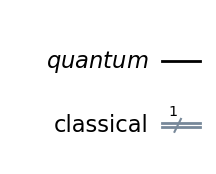

In [ ]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

qr = QuantumRegister(1, name="quantum")
cr = ClassicalRegister(1, name="classical")
qc = QuantumCircuit(qr, cr)
qc.draw("mpl", filename="quantum_circuit.png")

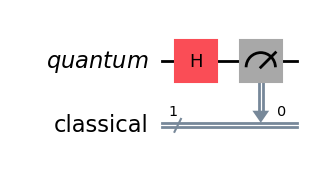

In [ ]:
qr = QuantumRegister(1, name="quantum")
cr = ClassicalRegister(1, name="classical")
qc = QuantumCircuit(qr, cr)
qc.h(0)
qc.measure(0,0)
qc.draw("mpl", filename="quantum_circuit.png")

In [ ]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.transpiler import generate_preset_pass_manager

from qiskit.circuit import QuantumCircuit
from qiskit.visualization import plot_histogram

In [ ]:

pm = generate_preset_pass_manager(optimization_level=1)
#qc= pm.run(bell)

# execute the quantum circuit
sampler = Sampler()
job = sampler.run([qc])
result = job.result()

print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(classical=BitArray(<shape=(), num_shots=1024, num_bits=1>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [ ]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.0 MB/s eta 0:00:00


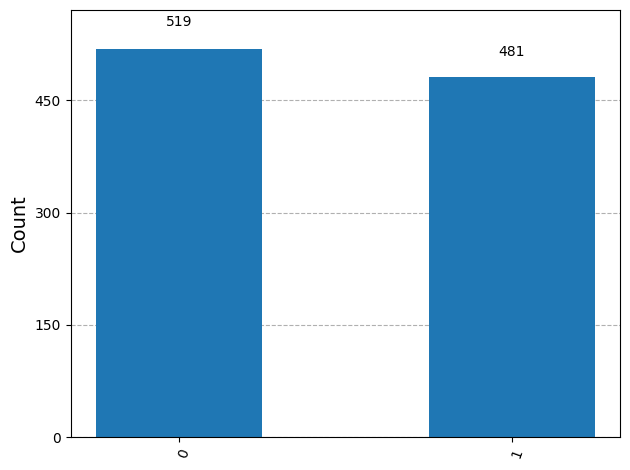

In [ ]:
counts = result.get_counts()
plot_histogram(counts)

## Bell

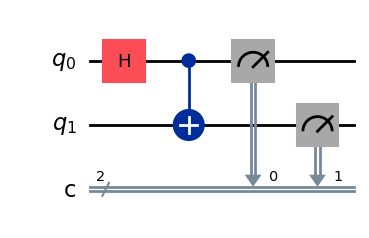

In [ ]:
# Crear circuito con 2 qubits y 2 bits clásicos
qc = QuantumCircuit(2, 2)

# Paso 1: Hadamard en el qubit 0
qc.h(0)

# Paso 2: CNOT con control=0 y target=1
qc.cx(0, 1)

# Medir ambos qubits
qc.measure([0, 1], [0, 1])

# Dibujar el circuito
qc.draw("mpl")

In [ ]:
print(counts)

{'0': 521, '1': 503}


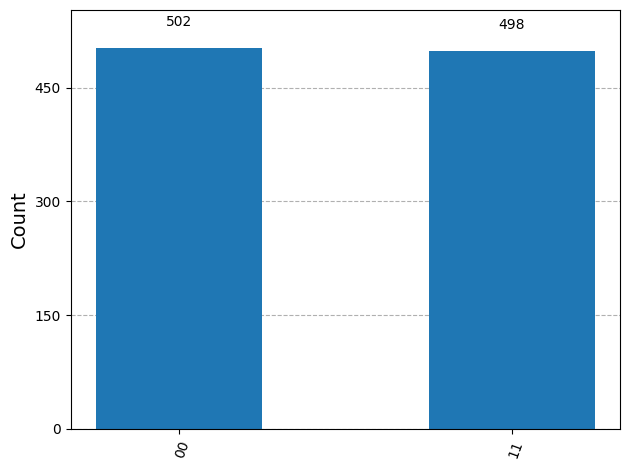

In [ ]:
fig = plot_histogram(counts)
display(fig)